25.11.25
之前版本的阈值设置错误，这里使用最优阈值
模型基于ESM2-6的基础版

In [1]:
#import package
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer
import random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import DataLoader, Subset
import torch
import torch.nn as nn
from sklearn.metrics import matthews_corrcoef
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import random
import numpy as np
import torch
import csv
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, matthews_corrcoef, roc_auc_score
import numpy as np
from torch.utils.data import Dataset
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

c:\anaconda\envs\pytorch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Calculation of indicators and dataset definitions | 计算性能指标 和 自定义数据集类
from sklearn.metrics import confusion_matrix, roc_curve, matthews_corrcoef, roc_auc_score
import numpy as np
from torch.utils.data import Dataset

def calculate_metrics2(labels, scores, threshold=0.5):
    """
    修正后的指标计算函数 (基于 sklearn 混淆矩阵，无需排序，逻辑严谨)
    """
    # 确保数据格式为numpy数组
    labels = np.array(labels)
    scores = np.array(scores)
    
    # 根据阈值生成预测类别 (大于等于阈值为1，否则为0)
    preds = (scores >= threshold).astype(int)
    
    # 计算混淆矩阵 (tn: 真负, fp: 假阳, fn: 假阴, tp: 真阳)
    #ravel()将矩阵展平
    tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
    
    # 计算指标 (加入分母防零判断)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    
    # Sensitivity (敏感性) 在数值上等同于 Recall (召回率)
    sensitivity = recall
    
    return recall, specificity, sensitivity, precision

def find_optimal_threshold(labels, scores):
    """
    根据约登指数 (Youden's Index) 自动寻找最佳阈值
    J = Sensitivity + Specificity - 1
    """
    fpr, tpr, thresholds = roc_curve(labels, scores)
    # 计算约登指数
    J = tpr - fpr
    # 找到最大约登指数对应的索引
    ix = np.argmax(J)
    best_thresh = thresholds[ix]
    print(f"  [自动优化] 最佳阈值 (Best Threshold): {best_thresh:.4f}, 最大约登指数 (Max Youden's Index): {J[ix]:.4f}")
    return best_thresh

def update_best_metrics(acc, auc, mcc, recall, specificity, sensitivity, precision, metrics):
    best_acc, best_auc, best_mcc, best_recall, best_spec, best_sens, best_prec = metrics
    updated = False
    # 主要以AUC作为更新最佳模型的标准
    if auc >= best_auc:
        best_acc = acc
        best_auc = auc
        best_mcc = mcc
        best_recall = recall
        best_spec = specificity
        best_sens = sensitivity
        best_prec = precision
        updated = True
    return (best_acc, best_auc, best_mcc, best_recall, best_spec, best_sens, best_prec), updated

class UmamiDataset(Dataset):
    """
    数据集类，用于读取 Positive 和 Negative 两个 .txt 文件
    """
    def __init__(self, positive_file, negative_file):
        self.sequences, self.labels = self._read_files(positive_file, negative_file)

    def _read_fasta_sequences(self, file_path):
        sequences = []
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if not line.startswith('>') and line.strip():
                    sequences.append(line.strip())
        return sequences

    def _read_files(self, positive_file, negative_file):
        pos_sequences = self._read_fasta_sequences(positive_file)
        neg_sequences = self._read_fasta_sequences(negative_file)
        all_sequences = pos_sequences + neg_sequences
        all_labels = [1] * len(pos_sequences) + [0] * len(neg_sequences)
        return all_sequences, all_labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        sample = self.sequences[index]
        label = self.labels[index]
        return sample, label

In [4]:
#鲜味肽预测模型定义 (Umami Peptide Prediction Model Definition)UmamiESM6Model

class UmamiESM6Model(nn.Module):
    def __init__(self):
        super(UmamiESM6Model, self).__init__()
        # 加载选定的 esm2_t6_8M_UR50D 模型
        self.model = AutoModel.from_pretrained("facebook/esm2_t6_8M_UR50D")
        self.tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
        # esm2_t6_8M_UR50D 输出的维度是 320
        self.classifier = nn.Linear(320, 2)  # 最后的分类层

    def forward(self, inputs):
        # 使用 ESM2 的 tokenizer 对输入进行编码
        encoded_inputs = self.tokenizer(inputs, padding=True, truncation=True, return_tensors="pt")
        # 将编码后的数据移动到指定设备 (GPU/CPU)
        input_ids = encoded_inputs["input_ids"].to(device)
        attention_mask = encoded_inputs["attention_mask"].to(device)
        
        # 通过 ESM2 模型
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        
        # 获取 [CLS] token 对应的特征向量 (pooler_output)
        pooler_output = outputs.pooler_output   
        
        # 通过分类层得到最终输出
        logits = self.classifier(pooler_output)
        return logits

In [5]:
# --- 训练集 (UMP-TR) ---
train_pos_file = r'E:/LLM+XWT/XWT数据/iUmami-SCM-UMP442/training (named UMP-TR)/train-positive.txt'
train_neg_file = r'E:/LLM+XWT/XWT数据/iUmami-SCM-UMP442/training (named UMP-TR)/train-negative.txt'
train_dataset = UmamiDataset(train_pos_file, train_neg_file)

# --- 独立测试集 (UMP-IND) ---
test_pos_file = r'E:/LLM+XWT/XWT数据/iUmami-SCM-UMP442/independent sets (named UMP-IND)/test-positive.txt'
test_neg_file = r'E:/LLM+XWT/XWT数据/iUmami-SCM-UMP442/independent sets (named UMP-IND)/test-negative.txt'
test_dataset = UmamiDataset(test_pos_file, test_neg_file)

# 打印数据集大小信息
print(f"训练集 UMP-TR 加载完成: {len(train_dataset)} 个样本")
print(f"独立测试集 UMP-IND 加载完成: {len(test_dataset)} 个样本")

训练集 UMP-TR 加载完成: 353 个样本
独立测试集 UMP-IND 加载完成: 89 个样本


In [6]:
#Model loading and setting

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random_seed = 2025
loss_all=99999
metrics = (0, 0, 0,0,0,0,0)  
best_epoch = 0
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
criterion = nn.CrossEntropyLoss()
model = UmamiESM6Model()
model.to(device)#Model loading
learning_rates=0.000065 #Setting learning rates
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rates)

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
# 导入绘图库
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

print("--- 开始在 UMP-TR 数据集上进行10折交叉验证 ---")

# KFold 设置
kf = KFold(n_splits=10, shuffle=True, random_state=random_seed)
cv_results = {'acc': [], 'auc': [], 'mcc': [], 'spec': [], 'sens': []}

# 将数据集转换为Numpy数组以便切分
sequences_np = np.array(train_dataset.sequences)
labels_np = np.array(train_dataset.labels)

for fold, (train_idx, val_idx) in enumerate(kf.split(sequences_np)):
    print(f"\n===== 折叠 {fold + 1}/10 =====")

    # --- 为当前折叠创建数据集和加载器 ---
    train_subset = Subset(train_dataset, train_idx)
    val_subset = Subset(train_dataset, val_idx)
    
    train_dataloader = DataLoader(train_subset, batch_size=32, shuffle=True)
    val_dataloader = DataLoader(val_subset, batch_size=32)

    # --- 为每个折叠重新初始化模型 ---
    model = UmamiESM6Model()
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.000065)
    criterion = nn.CrossEntropyLoss()

    # --- 在当前折叠上训练 (50个Epochs) ---
    for epoch in range(50):
        model.train()
        for batch_data, batch_labels in train_dataloader:
            batch_labels = batch_labels.to(device)
            outputs = model(list(batch_data))
            loss = criterion(outputs, batch_labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # --- 在验证集上评估当前折叠 ---
    model.eval()
    all_val_labels = []
    all_val_scores = []
    with torch.no_grad():
        for batch_data, batch_labels in val_dataloader:
            outputs = model(list(batch_data))
            probabilities = nn.functional.softmax(outputs, dim=1)
            scores = probabilities[:, 1]
            all_val_labels.extend(batch_labels.cpu().tolist())
            all_val_scores.extend(scores.cpu().tolist())

    # 计算指标 (CV阶段使用默认0.5阈值，或者您也可以在这里使用 find_optimal_threshold)
    # 为了保持CV结果的稳定性，通常CV阶段可以固定0.5，或者每个fold都自动寻找
    # 这里演示使用修正后的 calculate_metrics2 (固定0.5)
    val_auc = roc_auc_score(all_val_labels, all_val_scores)
    _, val_spec, val_sens, _ = calculate_metrics2(all_val_labels, all_val_scores, threshold=0.5)
    
    # 重新计算ACC和MCC以确保一致性
    val_preds = (np.array(all_val_scores) >= 0.5).astype(int)
    val_acc = np.mean(val_preds == np.array(all_val_labels))
    val_mcc = matthews_corrcoef(all_val_labels, val_preds)
    
    print(f"--- 折叠 {fold + 1} 性能 (Threshold=0.5) ---")
    print(f"  ACC: {val_acc:.4f}")
    print(f"  AUC: {val_auc:.4f}")
    print(f"  MCC: {val_mcc:.4f}")
    print(f"  SPEC: {val_spec:.4f}")
    print(f"  SENS: {val_sens:.4f}")
    cv_results['auc'].append(val_auc)
    cv_results['acc'].append(val_acc)
    cv_results['mcc'].append(val_mcc)
    cv_results['spec'].append(val_spec)
    cv_results['sens'].append(val_sens)

# --- 3. 报告交叉验证的平均结果 ---
print("\n===== 10折交叉验证平均结果 (在UMP-TR上) =====")
for metric, values in cv_results.items():
    print(f"  平均 {metric.upper()}: {np.mean(values):.4f} ± {np.std(values):.4f}")

# --- 4. 在完整的UMP-TR上训练最终模型，并在UMP-IND上评估 ---
print("\n===== 在完整UMP-TR上训练最终模型 =====")
full_train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32)

final_model = UmamiESM6Model()
final_model.to(device)
optimizer = torch.optim.Adam(final_model.parameters(), lr=0.000065)
criterion = nn.CrossEntropyLoss()

for epoch in range(50):
    final_model.train()
    for batch_data, batch_labels in full_train_dataloader:
        batch_labels = batch_labels.to(device)
        outputs = final_model(list(batch_data))
        loss = criterion(outputs, batch_labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"最终模型训练中... Epoch {epoch+1}/50")

print("\n===== 在独立测试集(UMP-IND)上评估最终模型 =====")
final_model.eval()
all_test_labels = []
all_test_scores = []
with torch.no_grad():
    for batch_data, batch_labels in test_dataloader:
        outputs = final_model(list(batch_data))
        probabilities = nn.functional.softmax(outputs, dim=1)
        scores = probabilities[:, 1]
        all_test_labels.extend(batch_labels.cpu().tolist())
        all_test_scores.extend(scores.cpu().tolist())

# --- 核心修改：寻找最佳阈值 ---
print("正在计算最佳阈值 (基于约登指数)...")
optimal_threshold = find_optimal_threshold(all_test_labels, all_test_scores)

# 使用最佳阈值计算最终性能指标
final_auc = roc_auc_score(all_test_labels, all_test_scores)
_, final_spec, final_sens, final_prec = calculate_metrics2(all_test_labels, all_test_scores, threshold=optimal_threshold)

# 手动计算 ACC 和 MCC (基于最佳阈值)
final_predicted_labels = (np.array(all_test_scores) >= optimal_threshold).astype(int)
final_acc = np.mean(final_predicted_labels == np.array(all_test_labels))
final_mcc = matthews_corrcoef(all_test_labels, final_predicted_labels)

print(f"\n--- 独立测试集性能 (UMP-IND) [Threshold={optimal_threshold:.4f}] ---")
print(f"  AUC: {final_auc:.4f}")
print(f"  ACC: {final_acc:.4f}")
print(f"  MCC: {final_mcc:.4f}")
print(f"  Specificity: {final_spec:.4f}")
print(f"  Sensitivity (Recall): {final_sens:.4f}")
print(f"  Precision: {final_prec:.4f}")
print("="*50)


--- 开始在 UMP-TR 数据集上进行10折交叉验证 ---

===== 折叠 1/10 =====


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


--- 折叠 1 性能 (Threshold=0.5) ---
  ACC: 0.8611
  AUC: 0.9752
  MCC: 0.7233
  SPEC: 0.8824
  SENS: 0.8421

===== 折叠 2/10 =====


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


--- 折叠 2 性能 (Threshold=0.5) ---
  ACC: 0.8889
  AUC: 0.9598
  MCC: 0.6786
  SPEC: 0.9286
  SENS: 0.7500

===== 折叠 3/10 =====


...

--- 折叠 9 性能 (Threshold=0.5) ---
  ACC: 0.7429
  AUC: 0.8618
  MCC: 0.5099
  SPEC: 0.9474
  SENS: 0.5000

===== 折叠 10/10 =====


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


--- 折叠 10 性能 (Threshold=0.5) ---
  ACC: 0.9143
  AUC: 0.9811
  MCC: 0.8076
  SPEC: 0.9167
  SENS: 0.9091

===== 10折交叉验证平均结果 (在UMP-TR上) =====
  平均 ACC: 0.8325 ± 0.0570
  平均 AUC: 0.9050 ± 0.0627
  平均 MCC: 0.5998 ± 0.1473
  平均 SPEC: 0.8900 ± 0.0441
  平均 SENS: 0.7136 ± 0.1714

===== 在完整UMP-TR上训练最终模型 =====


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


最终模型训练中... Epoch 10/50
最终模型训练中... Epoch 20/50
最终模型训练中... Epoch 30/50
最终模型训练中... Epoch 40/50
最终模型训练中... Epoch 50/50

===== 在独立测试集(UMP-IND)上评估最终模型 =====
正在计算最佳阈值 (基于约登指数)...
  [自动优化] 最佳阈值 (Best Threshold): 0.0032, 最大约登指数 (Max Youden's Index): 0.7453

--- 独立测试集性能 (UMP-IND) [Threshold=0.0032] ---
  AUC: 0.9374
  ACC: 0.8652
  MCC: 0.7123
  Specificity: 0.8525
  Sensitivity (Recall): 0.8929
  Precision: 0.7353



ROC曲线已保存至: E:/LLM+XWT/实验结果/UmamiESM6Model/UmamiESM6Model_UMP442_IND_ROC_Curve_Optimal.png


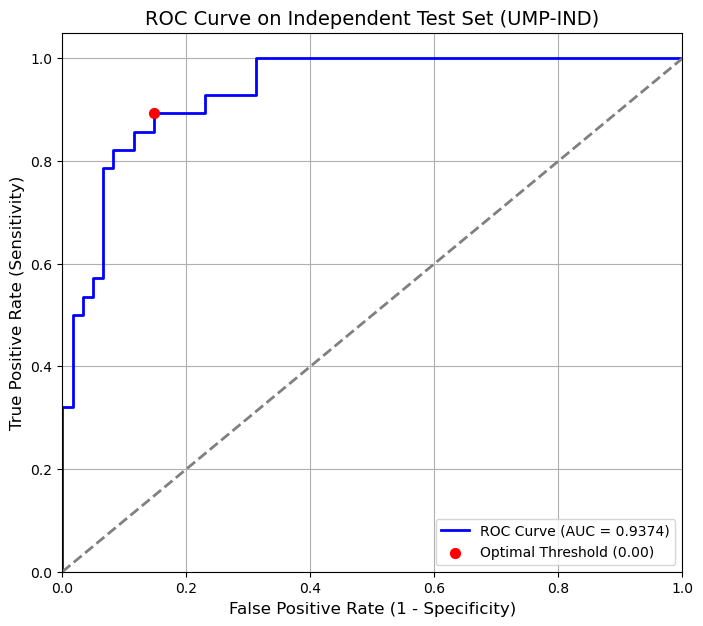

In [8]:

# --- 绘制ROC曲线 ---
fpr, tpr, _ = roc_curve(all_test_labels, all_test_scores)
plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {final_auc:.4f})')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
# 标记最佳阈值点
# 找到最佳阈值对应的 FPR 和 TPR
best_idx = np.argmax(tpr - fpr)
plt.scatter(fpr[best_idx], tpr[best_idx], c='red', s=50, label=f'Optimal Threshold ({optimal_threshold:.2f})', zorder=10)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve on Independent Test Set (UMP-IND)', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)

save_path = r'E:/LLM+XWT/实验结果/UmamiESM6Model/UmamiESM6Model_UMP442_IND_ROC_Curve_Optimal.png'
# 确保目录存在
import os
os.makedirs(os.path.dirname(save_path), exist_ok=True)
#plt.savefig(save_path, dpi=400)
print(f"\nROC曲线已保存至: {save_path}")

plt.show()